# Semana 4: Evaluación del modelo

iendo los datos


FuelConsumption.csv,  contiene la clasificaciones de consumo de combustible específicas del modelo y emisiones estimadas de dióxido de carbono para vehículos livianos nuevos en el mercado Canadiense del año 2014 [Dataset](https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODELYEAR** : Año del modelo, todos son del 2014
- **MAKE** : Marca del auto
- **MODEL** : Modelo
- **VEHICLE CLASS**  : Tipo de vehiculo
- **ENGINE SIZE** : Tamaño del motor (total del desplazamiento de todos los cilindros en litros)
- **CYLINDERS** : Número de cilindros
- **TRANSMISSION** : TIpo de transmisión
- **FUEL CONSUMPTION in CITY(L/100 km)** : Consumo de combustible en litros por km en la ciudad.
- **FUEL CONSUMPTION in HWY (L/100 km)** : Consumo de combustible en litros por km en la autopista.
- **FUEL CONSUMPTION COMB (L/100 km)** : Consumo de combustible en litros por km en ciudad  y autopista.
- **CO2 EMISSIONS (g/km)** : Emisiones de CO2 en gramos por kilometro 

Ref English : https://www.nrcan.gc.ca/energy-efficiency/transportation-alternative-fuels/personal-vehicles/choosing-right-vehicle/buying-electric-vehicle/understanding-the-tables/21383

https://natural-resources.canada.ca/energy-efficiency/transportation-alternative-fuels/personal-vehicles/choosing-right-vehicle/buying-electric-vehicle/understanding-the-tables/21383?_ga=2.17279097.1124743014.1634751700-1134974499.1634751700

In [147]:
'''
Curso: Análisis de Datos con Python
Sesión 4: Evaluación del modelo
Fecha: 03/08/2024
Autor: José Espinoza Melgarejo
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [148]:
df = pd.read_csv("dataset/FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [149]:
df.dtypes

MODELYEAR                     int64
MAKE                         object
MODEL                        object
VEHICLECLASS                 object
ENGINESIZE                  float64
CYLINDERS                     int64
TRANSMISSION                 object
FUELTYPE                     object
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object

In [150]:
df.isnull().sum()

MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64

In [151]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [152]:
df.describe(include=[object])

,MAKE,MODEL,VEHICLECLASS,TRANSMISSION,FUELTYPE
count,1067,1067,1067,1067,1067
unique,39,663,16,22,4
top,FORD,F150 FFV,MID-SIZE,A6,X
freq,90,8,178,222,514


In [153]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


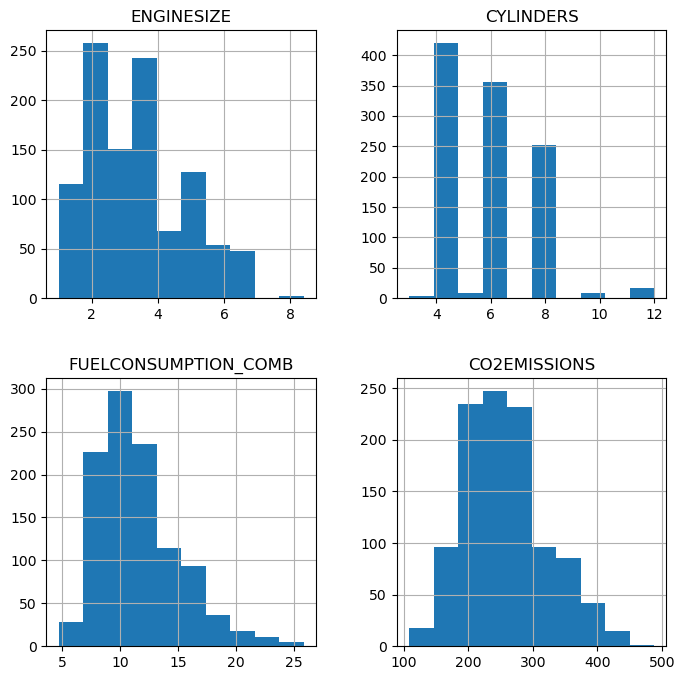

In [154]:
df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]. \
                     hist(layout=(2,2), sharex=False, sharey=False, figsize=(8,8))
plt.show()

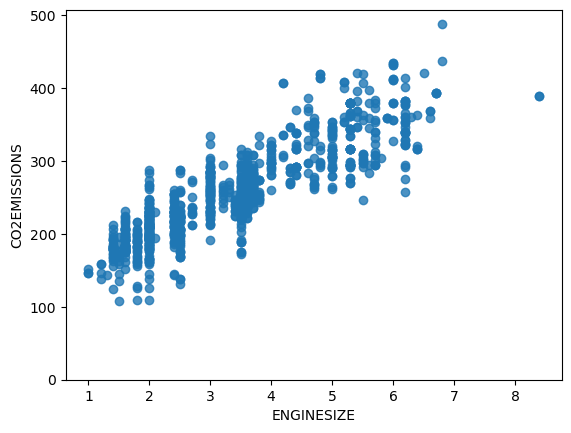

In [155]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=cdf, fit_reg=False)
plt.ylim(0,)
plt.show()

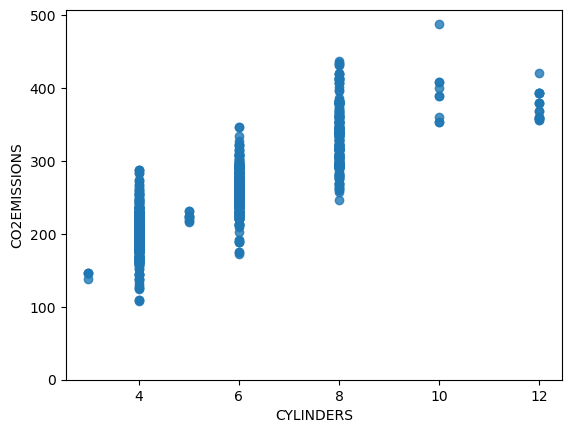

In [156]:
sns.regplot(x="CYLINDERS", y="CO2EMISSIONS", data=cdf, fit_reg=False)
plt.ylim(0,)
plt.show()

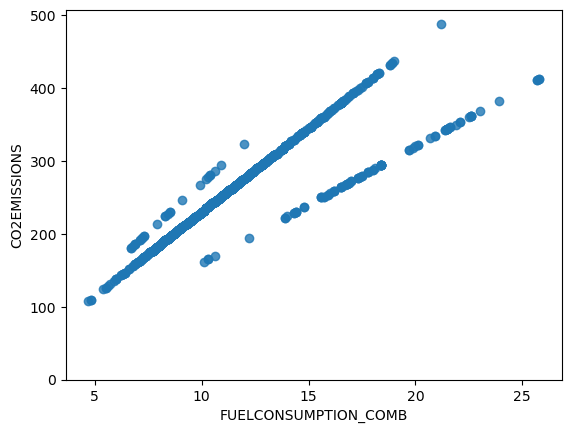

In [157]:
sns.regplot(x="FUELCONSUMPTION_COMB", y="CO2EMISSIONS", data=cdf, fit_reg=False)
plt.ylim(0,)
plt.show()

In [158]:
X = cdf[['ENGINESIZE']]
y = cdf[['CO2EMISSIONS']]
print("Número de datos =", len(cdf))

Número de datos = 1067


In [159]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Número de datos de entrenamiento para X =", len(X_train))
print("Número de datos de prueba para X =", len(X_test))
print("")
print("Número de datos de entrenamiento para X =", X_train.shape[0])
print("Número de datos de prueba para X =", X_test.shape[0])

Número de datos de entrenamiento para X = 853
Número de datos de prueba para X = 214

Número de datos de entrenamiento para X = 853
Número de datos de prueba para X = 214


In [160]:
# Regresión simple usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [161]:
b0 = lm.intercept_
b1 = lm.coef_
print('Intercepto =', b0)
print('Coeficiente =', b1)

Intercepto = [126.18920155]
Coeficiente = [[39.24838431]]


$$ \hat{y} =  126.189 + 39.248x $$

In [162]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train["CO2EMISSIONS_HAT"] = b0[0] + (b1[0][0])*df_train["ENGINESIZE"]
df_train["ERROR"] =  df_train["CO2EMISSIONS"] - df_train["CO2EMISSIONS_HAT"]
df_train.head()

,ENGINESIZE,CO2EMISSIONS,CO2EMISSIONS_HAT,ERROR
270,3.6,290,267.483385,22.516615
1006,4.6,347,306.731769,40.268231
728,3.5,244,263.558547,-19.558547
992,2.5,218,224.310162,-6.310162
702,1.5,170,185.061778,-15.061778


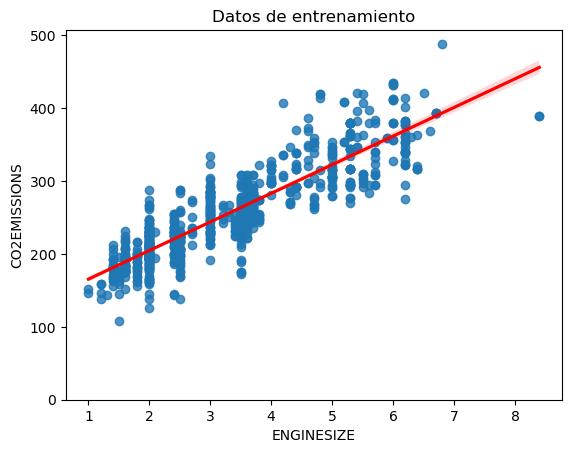

In [163]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=df_train, fit_reg=True,
            line_kws={"color": "red"})
plt.ylim(0,)
plt.title('Datos de entrenamiento')
plt.show()

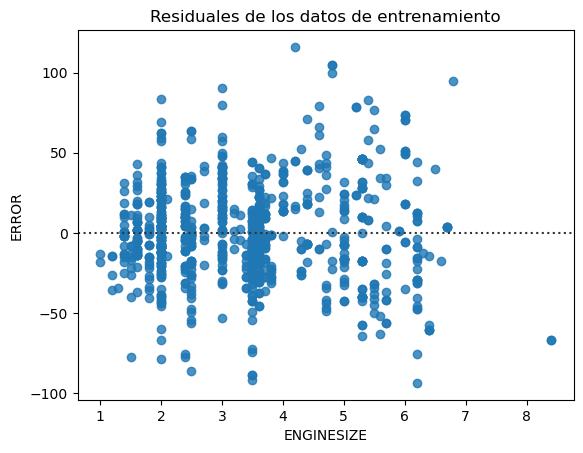

In [164]:
sns.residplot(x="ENGINESIZE", y="ERROR", data=df_train)
plt.title('Residuales de los datos de entrenamiento')
plt.show()

In [165]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test["CO2EMISSIONS_HAT"] = b0[0] + (b1[0][0])*df_test["ENGINESIZE"]
df_test["ERROR"] =  df_test["CO2EMISSIONS"] - df_test["CO2EMISSIONS_HAT"]
df_test.head()

,ENGINESIZE,CO2EMISSIONS,CO2EMISSIONS_HAT,ERROR
766,5.5,356,342.055315,13.944685
204,2.4,209,220.385324,-11.385324
629,2.4,230,220.385324,9.614676
897,2.7,212,232.159839,-20.159839
711,2.5,168,224.310162,-56.310162


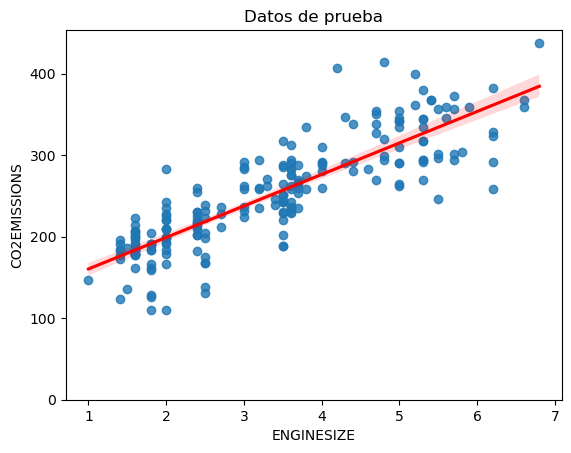

In [166]:
sns.regplot(x="ENGINESIZE", y="CO2EMISSIONS", data=df_test, fit_reg=True, 
            line_kws={"color": "red"})
plt.ylim(0,)
plt.title('Datos de prueba')
plt.show()

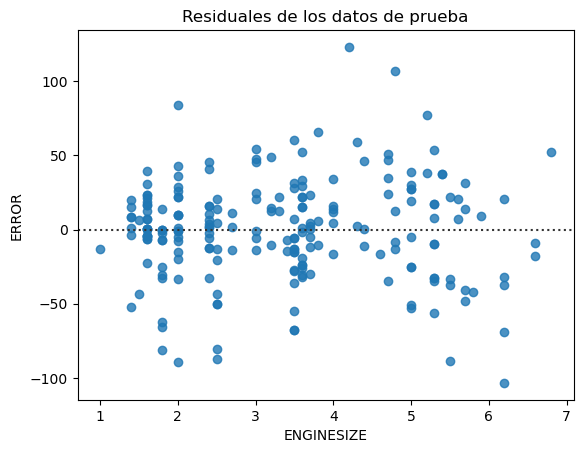

In [167]:
sns.residplot(x="ENGINESIZE", y="ERROR", data=df_test)
plt.title('Residuales de los datos de prueba')
plt.show()

In [168]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_train_hat = lm.predict(X_train)
print("MSE = %.2f" % mean_squared_error(y_train, y_train_hat))
print("R2 = %.4f" % r2_score(y_train, y_train_hat))

MSE = 889.45
R2 = 0.7749


In [169]:
y_test_hat = lm.predict(X_test)
print("MSE = %.2f" % mean_squared_error(y_test, y_test_hat))
print("R2 = %.4f" % r2_score(y_test, y_test_hat))

MSE = 1181.53
R2 = 0.7201


In [170]:
X = cdf[['ENGINESIZE']]
y = cdf[['CO2EMISSIONS']]
model = LinearRegression()

In [171]:
from sklearn.model_selection import cross_val_predict
y_hat = cross_val_predict(model, X, y, cv=5)
y_hat[0:5]

array([[201.70277046],
       [217.41090047],
       [182.06760795],
       [260.608258  ],
       [260.608258  ]])

In [172]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("Los R2 son:", scores)
print("")
print("El promedio de los R2 es", scores.mean())

Los R2 son: [0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]

El promedio de los R2 es 0.7543767707250393


In [173]:
from sklearn.model_selection import cross_validate
list_scoring = ('r2', 'neg_mean_squared_error')
scores = cross_validate(model, X, y, cv=5, scoring=list_scoring,
                        return_train_score=False)
df_scores = pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_r2,test_neg_mean_squared_error
0,0.002144,0.002017,0.743346,-880.019764
1,0.001458,0.001794,0.783828,-1055.037158
2,0.001262,0.001231,0.728020,-1075.619670
3,0.000866,0.001038,0.730329,-1023.274235
4,0.001369,0.001199,0.786361,-747.383399


In [174]:
NEG_MSE_test = scores['test_neg_mean_squared_error']
R2_test = scores['test_r2']
MSE_test = -NEG_MSE_test
print("Los MSE son:", MSE_test)
print("La media de los MSE es:", np.mean(MSE_test))
print("Los R2 son:", R2_test)
print("La media de los R2 es:", np.mean(R2_test))

Los MSE son: [ 880.01976439 1055.03715804 1075.61966982 1023.27423464  747.38339934]
La media de los MSE es: 956.2668452461579
Los R2 son: [0.74334613 0.7838278  0.72801992 0.73032948 0.78636053]
La media de los R2 es: 0.7543767707250393


In [175]:
list_scoring = ('r2', 'neg_mean_squared_error')
scores = cross_validate(model, X, y, cv=5, scoring=list_scoring,
                        return_train_score=True)
df_scores= pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_r2,train_r2,test_neg_mean_squared_error,train_neg_mean_squared_error
0,0.002405,0.001784,0.743346,0.764833,-880.019764,-966.430448
1,0.001656,0.001412,0.783828,0.757121,-1055.037158,-919.550324
2,0.000936,0.000795,0.728020,0.772190,-1075.619670,-914.742235
3,0.000603,0.000617,0.730329,0.769227,-1023.274235,-928.436812
4,0.000452,0.000574,0.786361,0.756613,-747.383399,-996.858715


In [176]:
NEG_MSE_train = scores['train_neg_mean_squared_error']
R2_train = scores['train_r2']
MSE_train = -NEG_MSE_train
print("Los MSE son:", MSE_train)
print("La media de los MSE es:", np.mean(MSE_train))
print("Los R2 son:", R2_train)
print("La media de los R2 es:", np.mean(R2_train))

Los MSE son: [966.43044831 919.5503243  914.74223494 928.43681233 996.85871542]
La media de los MSE es: 945.2037070617034
Los R2 son: [0.76483329 0.75712109 0.77218984 0.76922695 0.75661337]
La media de los R2 es: 0.763996907116833


In [177]:
from sklearn.model_selection import cross_validate
coeficientes_modelos = cross_validate(model, X, y, cv=5,
                                      return_estimator=True)
df_coeficientes_modelos= pd.DataFrame(coeficientes_modelos)
df_coeficientes_modelos

,fit_time,score_time,estimator,test_score
0,0.004257,0.001256,LinearRegression(),0.743346
1,0.001702,0.000930,LinearRegression(),0.783828
2,0.000741,0.000702,LinearRegression(),0.728020
3,0.001428,0.000980,LinearRegression(),0.730329
4,0.001057,0.000946,LinearRegression(),0.786361


In [178]:
i = 1 
for model in df_coeficientes_modelos['estimator']:
    print("Modelo %s: intercepto = %s, pendiente = %s "%(i, model.intercept_, model.coef_))
    i += 1

Modelo 1: intercepto = [123.1621204], pendiente = [[39.27032503]] 
Modelo 2: intercepto = [126.88538406], pendiente = [[38.77237039]] 
Modelo 3: intercepto = [123.51055848], pendiente = [[39.51513913]] 
Modelo 4: intercepto = [126.14743687], pendiente = [[39.17922779]] 
Modelo 5: intercepto = [127.10513638], pendiente = [[38.80652617]] 


In [196]:
def distribution_plot(RedFunction, BlueFunction, RedName, BlueName, Title):
    plt.figure(figsize=(6, 6))
    ax1 = sns.distplot(RedFunction, hist=False, color="r", label=RedName)
    ax2 = sns.distplot(BlueFunction, hist=False, color="b", label=BlueName, ax=ax1)
    plt.title(Title)
    plt.xlabel('Emisión de CO2')
    plt.ylabel('Proporción de autos')
    plt.show()

def distribution_plot(RedFunction, BlueFunction, RedName, BlueName, Title):
    plt.figure(figsize=(6, 6))
    sns.kdeplot(RedFunction, color="red", label=RedName, linewidth=1)
    sns.kdeplot(BlueFunction, color="blue", label=BlueName, linewidth=1, linestyle='--')
    plt.title(Title)
    plt.xlabel('Emisión de CO2')
    plt.ylabel('Proporción de autos')
    plt.legend()
    plt.show()

In [197]:
def poly_plot(X_train, X_test, y_train, y_test, lr, poly_transform):
    plt.figure(figsize=(6, 6))    
    x_max = max([X_train.values.max(), X_test.values.max()])
    x_min = min([X_train.values.min(), X_test.values.min()])
    x = np.arange(x_min, x_max, 0.1)
    plt.plot(X_train, y_train, 'ro', label='Datos de entrenamiento')
    plt.plot(X_test, y_test, 'go', label='Datos de prueba')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Función predicha')
    plt.ylabel('Consumo de CO2')
    plt.legend()

In [198]:
from sklearn.linear_model import LinearRegression
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

LinearRegression()

In [199]:
y_train_pred = modelo_simple.predict(X_train)
y_train_pred[0:5]

array([[267.48338507],
       [306.73176938],
       [263.55854664],
       [224.31016233],
       [185.06177802]])

In [200]:
y_test_pred = modelo_simple.predict(X_test)
y_test_pred[0:5]

array([[342.05531526],
       [220.3853239 ],
       [220.3853239 ],
       [232.15983919],
       [224.31016233]])

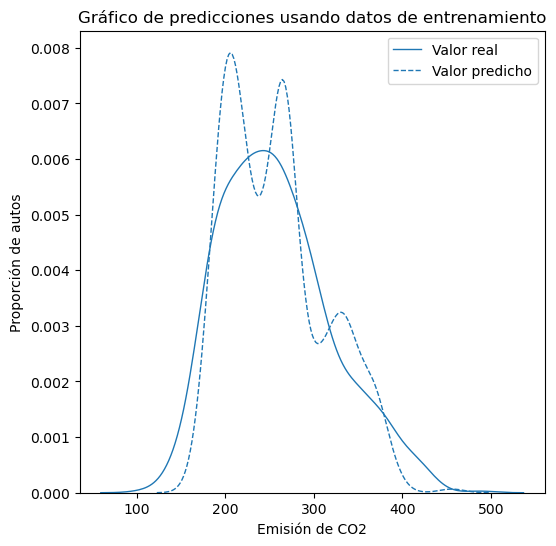

In [ ]:

Title = 'Gráfico de predicciones usando datos de entrenamiento'
distribution_plot(y_train, y_train_pred, "Valor real", "Valor predicho", Title)

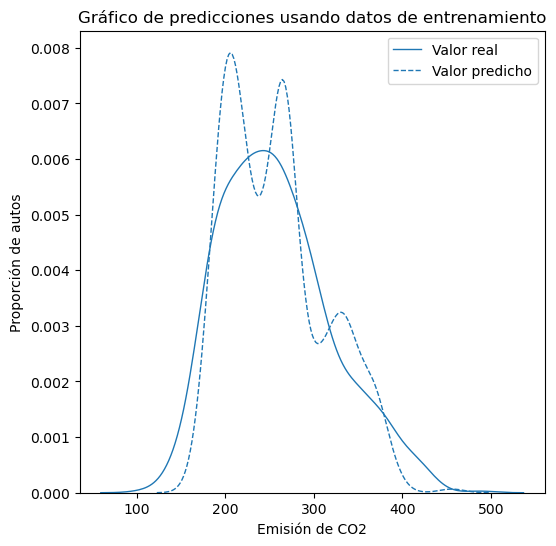

In [202]:
Title = 'Gráfico de predicciones usando datos de entrenamiento'
distribution_plot(y_train, y_train_pred, "Valor real", "Valor predicho", Title)

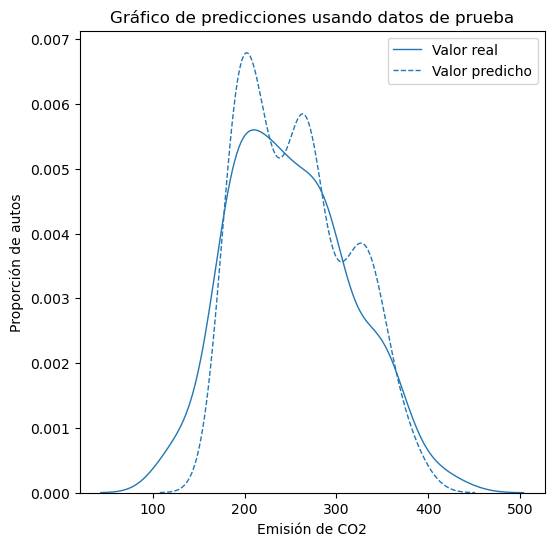

In [203]:
Title = 'Gráfico de predicciones usando datos de prueba'
distribution_plot(y_test, y_test_pred, "Valor real", "Valor predicho", Title)

In [204]:
from sklearn.preprocessing import PolynomialFeatures
pr = PolynomialFeatures(degree=5)
X_train_pr = pr.fit_transform(X_train)
X_test_pr = pr.fit_transform(X_test)

lr = LinearRegression()
lr.fit(X_train_pr, y_train)

LinearRegression()

In [205]:
y_pred = lr.predict(X_test_pr)
print("Valor real:\n", y_test[0:5].values)
print("Valor predicho:\n", y_pred[0:5])
poly_plot(X_train, X_test, y_train, y_test, lr, pr)

Valor real:
 [[356]
 [209]
 [230]
 [212]
 [168]]
Valor predicho:
 [[345.80541076]
 [221.27071494]
 [221.27071494]
 [232.3768919 ]
 [224.99288145]]


In [206]:
X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf[['CO2EMISSIONS']]
print("Número de datos =", len(X))

Número de datos = 1067


In [207]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Número de datos de entrenamiento para X =", len(X_train))
print("Número de datos de prueba para X =", len(X_test))
print("")
print("Número de datos de entrenamiento para X =", X_train.shape[0])
print("Número de datos de prueba para X =", X_test.shape[0])

Número de datos de entrenamiento para X = 853
Número de datos de prueba para X = 214

Número de datos de entrenamiento para X = 853
Número de datos de prueba para X = 214


In [208]:
# Regresión simple usando la librería sklearn
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [209]:
b0 = lm.intercept_
b = lm.coef_
print('Intercepto =', b0)
print('Coeficientes =', b)

Intercepto = [69.05220993]
Coeficientes = [[11.98993058  7.54469599  8.98695981]]


$$ \hat{y} = 69.052 + 11.990x_{1} + 7.545x_{2} + 8.987x_{3} $$

In [210]:
df_train = pd.concat([X_train, y_train], axis=1)
df_train["CO2EMISSIONS_HAT"] = b0[0] + (b[0][0])*df_train["ENGINESIZE"] + \
                                       (b[0][1])*df_train["CYLINDERS"] + \
                                       (b[0][2])*df_train["FUELCONSUMPTION_COMB"]  
df_train["ERROR"] =  df_train["CO2EMISSIONS"] - df_train["CO2EMISSIONS_HAT"]
df_train.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS,CO2EMISSIONS_HAT,ERROR
270,3.6,6,12.6,290,270.719830,19.280170
1006,4.6,8,15.1,347,320.266552,26.733448
728,3.5,6,10.6,244,251.546917,-7.546917
992,2.5,4,9.5,218,214.581939,3.418061
702,1.5,4,7.4,170,183.719392,-13.719392


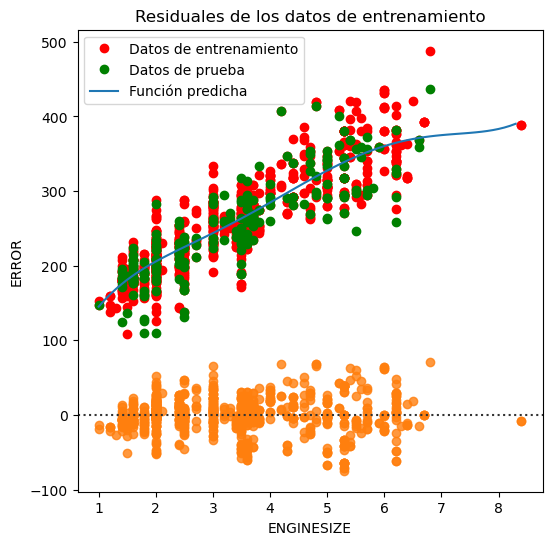

In [211]:
sns.residplot(x="ENGINESIZE", y="ERROR", data=df_train)
plt.title('Residuales de los datos de entrenamiento')
plt.show()

In [121]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test["CO2EMISSIONS_HAT"] = b0[0] + (b[0][0])*df_test["ENGINESIZE"] + \
                                      (b[0][1])*df_test["CYLINDERS"] + \
                                      (b[0][2])*df_test["FUELCONSUMPTION_COMB"]  
df_test["ERROR"] =  df_test["CO2EMISSIONS"] - df_test["CO2EMISSIONS_HAT"]
df_test.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS,CO2EMISSIONS_HAT,ERROR
766,5.5,8,15.5,356,334.652273,21.347727
204,2.4,4,9.1,209,209.788162,-0.788162
629,2.4,4,10.0,230,217.876425,12.123575
897,2.7,6,9.2,212,229.373229,-17.373229
711,2.5,4,7.3,168,194.810627,-26.810627


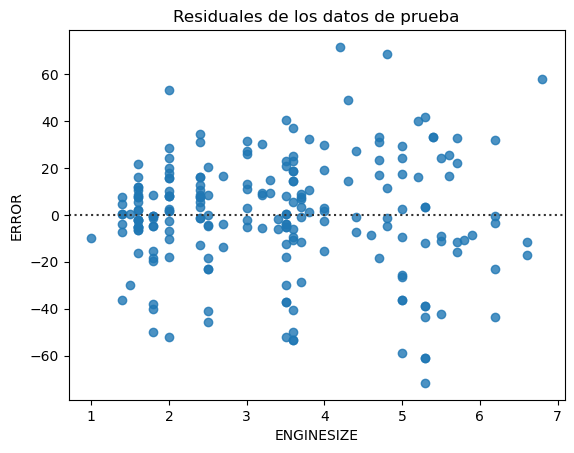

In [122]:
sns.residplot(x="ENGINESIZE", y="ERROR", data=df_test)
plt.title('Residuales de los datos de prueba')
plt.show()

In [212]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
y_train_hat = lm.predict(X_train)
print("MSE = %.2f" % mean_squared_error(y_train, y_train_hat))
print("R2 = %.4f" % r2_score(y_train, y_train_hat))

MSE = 537.30
R2 = 0.8640


In [213]:
y_test_hat = lm.predict(X_test)
print("MSE = %.2f" % mean_squared_error(y_test, y_test_hat))
print("R2 = %.4f" % r2_score(y_test, y_test_hat))

MSE = 589.24
R2 = 0.8604


In [125]:
model = LinearRegression()
X = cdf[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y = cdf[['CO2EMISSIONS']]

In [214]:
from sklearn.model_selection import cross_val_predict
y_hat = cross_val_predict(model, X, y, cv=5)
y_hat[0:5]

array([[197.85729058],
       [213.51019289],
       [167.07288207],
       [253.69077044],
       [249.11188039]])

In [215]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="r2")
print("Los R2 son:", scores)
print("El promedio de los R2 es", scores.mean())

Los R2 son: [0.88051915 0.76909654 0.81958305 0.88490155 0.89558377]
El promedio de los R2 es 0.8499368120958023


In [216]:
from sklearn.model_selection import cross_validate
list_scoring = ('r2', 'neg_mean_squared_error')
scores = cross_validate(model, X, y, cv=5, scoring=list_scoring, 
                        return_train_score=False)
df_scores = pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_r2,test_neg_mean_squared_error
0,0.002076,0.001689,0.880519,-409.678242
1,0.001972,0.001407,0.769097,-1126.933655
2,0.001341,0.001228,0.819583,-713.508189
3,0.000937,0.001113,0.884902,-436.745121
4,0.000842,0.000988,0.895584,-365.283424


In [217]:
NEG_MSE_test = scores['test_neg_mean_squared_error']
R2_test = scores['test_r2']
MSE_test = -NEG_MSE_test
print("Los MSE son:", MSE_test)
print("La media de los MSE es:", np.mean(MSE_test))
print("Los R2 son:", R2_test)
print("La media de los R2 es:", np.mean(R2_test))

Los MSE son: [ 409.67824154 1126.93365483  713.50818876  436.74512061  365.28342353]
La media de los MSE es: 610.4297258541549
Los R2 son: [0.88051915 0.76909654 0.81958305 0.88490155 0.89558377]
La media de los R2 es: 0.8499368120958023


In [218]:
list_scoring = ('r2', 'neg_mean_squared_error')
scores = cross_validate(model, X, y, cv=5, scoring=list_scoring,
                        return_train_score=True)
df_scores= pd.DataFrame(scores)
df_scores

,fit_time,score_time,test_r2,train_r2,test_neg_mean_squared_error,train_neg_mean_squared_error
0,0.002983,0.002384,0.880519,0.857538,-409.678242,-585.454563
1,0.001134,0.001177,0.769097,0.885363,-1126.933655,-434.021830
2,0.000936,0.001131,0.819583,0.873981,-713.508189,-506.011106
3,0.001299,0.001245,0.884902,0.856889,-436.745121,-575.758076
4,0.000940,0.001300,0.895584,0.854763,-365.283424,-594.860415


In [219]:
NEG_MSE_train = scores['train_neg_mean_squared_error']
R2_train = scores['train_r2']
MSE_train = -NEG_MSE_train
print("Los MSE son:", MSE_train)
print("La media de los MSE es:", np.mean(MSE_train))
print("Los R2 son:", R2_train)
print("La media de los R2 es:", np.mean(R2_train))

Los MSE son: [585.45456309 434.02182959 506.01110641 575.75807607 594.86041529]
La media de los MSE es: 539.2211980884638
Los R2 son: [0.85753819 0.88536272 0.87398147 0.85688908 0.8547627 ]
La media de los R2 es: 0.8657068321922399


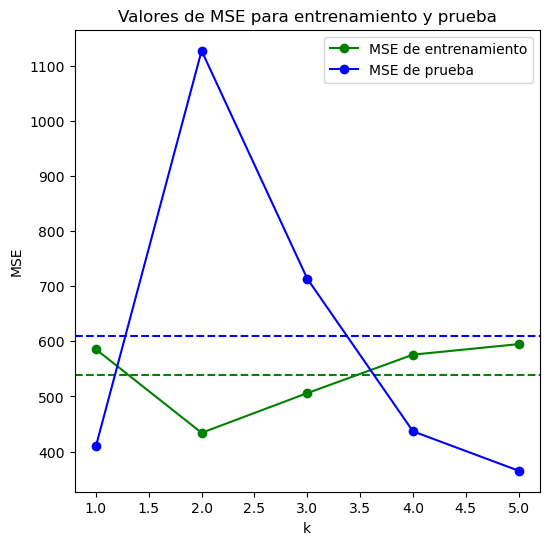

In [220]:
k = np.arange(1,len(MSE_train)+1)
plt.figure(figsize=(6,6))
plt.title('Valores de MSE para entrenamiento y prueba')
plt.plot(k,MSE_train,marker='o',linestyle='-',color='g',label='MSE de entrenamiento')
plt.axhline(y=np.mean(MSE_train),color='g',linestyle='--')
plt.plot(k,MSE_test,marker='o',linestyle='-',color='b',label='MSE de prueba')
plt.axhline(y=np.mean(MSE_test),color='b',linestyle='--')
plt.legend()
plt.xlabel('k')
plt.ylabel('MSE')
plt.show()

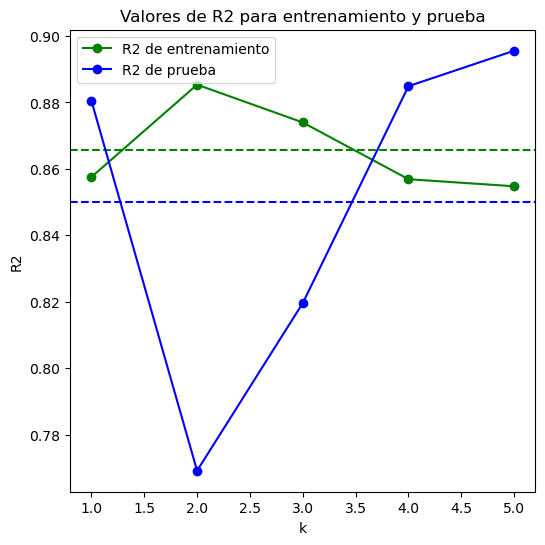

In [221]:
k = np.arange(1,len(MSE_train)+1)
plt.figure(figsize=(6,6))
plt.title('Valores de R2 para entrenamiento y prueba')
plt.plot(k,R2_train,marker='o',linestyle='-',color='g',label='R2 de entrenamiento')
plt.axhline(y=np.mean(R2_train),color='g',linestyle='--')
plt.plot(k,R2_test,marker='o',linestyle='-',color='b',label='R2 de prueba')
plt.axhline(y=np.mean(R2_test),color='b',linestyle='--')
plt.legend()
plt.xlabel('k')
plt.ylabel('R2')
plt.show()

In [134]:
X = cdf[["ENGINESIZE","CYLINDERS","FUELCONSUMPTION_COMB"]]
y = cdf[["CO2EMISSIONS"]]
model = LinearRegression()

In [135]:
from sklearn.model_selection import cross_validate
coeficientes_modelos = cross_validate(model, X, y, cv=5,
                                      return_estimator=True)
df_coeficientes_modelos= pd.DataFrame(coeficientes_modelos)
df_coeficientes_modelos

,fit_time,score_time,estimator,test_score
0,0.001157,0.000660,LinearRegression(),0.880519
1,0.000689,0.000419,LinearRegression(),0.769097
2,0.000521,0.000399,LinearRegression(),0.819583
3,0.000481,0.000441,LinearRegression(),0.884902
4,0.000485,0.000388,LinearRegression(),0.895584


In [222]:
i = 1 
for model in df_coeficientes_modelos['estimator']:
    print("Modelo %s: intercepto = %s, pendientes = %s "%(i, model.intercept_, model.coef_))
    i += 1

Modelo 1: intercepto = [123.1621204], pendientes = [[39.27032503]] 
Modelo 2: intercepto = [126.88538406], pendientes = [[38.77237039]] 
Modelo 3: intercepto = [123.51055848], pendientes = [[39.51513913]] 
Modelo 4: intercepto = [126.14743687], pendientes = [[39.17922779]] 
Modelo 5: intercepto = [127.10513638], pendientes = [[38.80652617]] 


In [137]:
from sklearn.linear_model import LinearRegression
modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train, y_train)

LinearRegression()

In [223]:
y_train_pred = modelo_multiple.predict(X_train)
y_train_pred[0:5]

array([[270.71982954],
       [320.26655162],
       [251.54691687],
       [214.58193852],
       [183.71939234]])

In [224]:
y_test_pred = modelo_multiple.predict(X_test)
y_test_pred[0:5]

array([[334.65227307],
       [209.78816154],
       [217.87642537],
       [229.37322867],
       [194.81062694]])

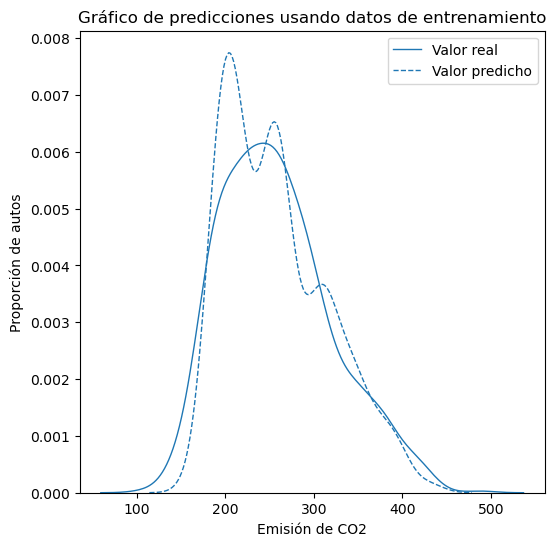

In [225]:
Title = 'Gráfico de predicciones usando datos de entrenamiento'
distribution_plot(y_train, y_train_pred, "Valor real", "Valor predicho", Title)

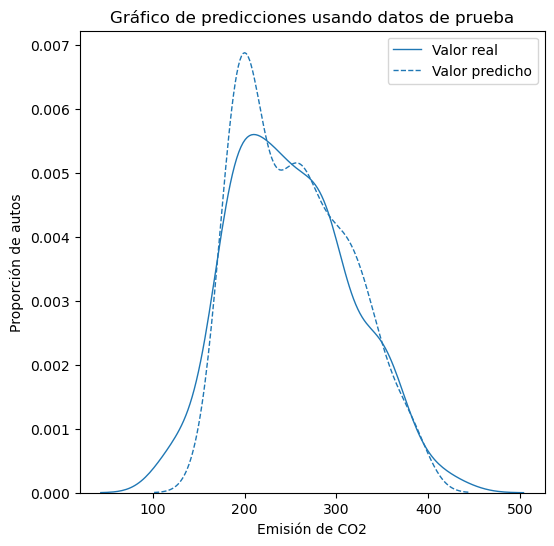

In [226]:
Title = 'Gráfico de predicciones usando datos de prueba'
distribution_plot(y_test, y_test_pred, "Valor real", "Valor predicho", Title)

In [227]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


In [143]:
# Regresión usando la librería statsmodels
import statsmodels.formula.api as smf
modelo1 = smf.ols('CO2EMISSIONS ~  ENGINESIZE', data=cdf).fit()
modelo2 = smf.ols('CO2EMISSIONS ~  CYLINDERS', data=cdf).fit()
modelo3 = smf.ols('CO2EMISSIONS ~  FUELCONSUMPTION_COMB', data=cdf).fit()
modelo4 = smf.ols('CO2EMISSIONS ~  ENGINESIZE + CYLINDERS + FUELCONSUMPTION_COMB', data=cdf).fit()

In [228]:
resultados = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4'],
    'AIC': [round(modelo1.aic, 2), round(modelo2.aic, 2), 
            round(modelo3.aic, 2), round(modelo4.aic, 2)],
    'BIC': [round(modelo1.bic, 2), round(modelo2.bic, 2), 
            round(modelo3.bic, 2), round(modelo4.bic, 2)]
})
resultados

,Modelo,AIC,BIC
0,Modelo 1,10343.71,10353.66
1,Modelo 2,10519.27,10529.22
2,Modelo 3,10189.45,10199.40
3,Modelo 4,9760.29,9780.18


In [229]:
for i in range(len(resultados)):
    if (resultados['AIC'][i] == np.min(resultados['AIC'])):
        min_AIC = resultados['AIC'][i]
        modelo_AIC = resultados['Modelo'][i]
    else:
        continue

print("Mejor modelo según AIC es", modelo_AIC, "con AIC =", min_AIC)

Mejor modelo según AIC es Modelo 4 con AIC = 9760.29


In [230]:
for i in range(len(resultados)):
    if (resultados['BIC'][i] == np.min(resultados['BIC'])):
        min_BIC = resultados['BIC'][i]
        modelo_BIC = resultados['Modelo'][i]
    else:
        continue

print("Mejor modelo según BIC es", modelo_BIC, "con BIC =", min_BIC)

Mejor modelo según BIC es Modelo 4 con BIC = 9780.18
